![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of findings and analysis
- Frame your 'story'

## Business Understanding
- Set the stage for analysis
- Why are these findings relevant/important?
- Introduce stakeholders
- Postulate about questions you want to ask/answer

## Data Understanding
- Present the source of data
- Describe the data available
- What is relevant to keep what is not
- Present any data cleaning that needs to happen
- Null values? Type mismatches? Duplicates?

In [139]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [140]:
# EDA Code Here - Create New Cells As Needed
# LOAD DATASET
df = pd.read_csv('google_play_store_dataset.csv')

print(f"Dataset shape: {df.shape} rows, {df.shape[1]} columns")
print("First 5 rows:")
df.head()

Dataset shape: (10841, 13) rows, 13 columns
First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.90,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.50,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.30,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [141]:
#Information and missing values
print("\nData types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistic's summary:")
df.describe()


Data types:
App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Statistic's summary:


,Rating
count,9367.00
mean,4.19
std,0.54
min,1.00
25%,4.00
50%,4.30
75%,4.50
max,19.00


## Data Preparation



In [142]:
# Data Prep Code Here

#Data Cleaning
df_clean = df.copy()
df_clean = df_clean[df_clean['Installs'] != 'Free']

# 1. Missing Ratings
df_clean = df_clean.dropna(subset=['Rating'])

# 2. Installs 
def clean_installs(val):
    if isinstance(val, str):
        val = val.replace(',', '').replace('+', '').strip()
        if val == 'Free' or val == '':
            return np.nan
        try:
            return int(val)
        except ValueError:
            return np.nan
    try:
        return int(val)
    except (ValueError, TypeError):
        return np.nan

df_clean['Installs'] = df_clean['Installs'].apply(clean_installs)

# 3. Price
def clean_price(val):
    if isinstance(val, str):
        val = val.replace('$', '').strip()
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df_clean['Price'] = df_clean['Price'].apply(clean_price)

# 4. Reviews 
def clean_reviews(val):
    if isinstance(val, str):
        val = val.strip()
        if val.endswith('M'):
            try:
                return int(float(val[:-1]) * 1_000_000)
            except ValueError:
                return np.nan
        val = val.replace(',', '')
    try:
        return int(float(val))
    except (ValueError, TypeError):
        return np.nan

df_clean['Reviews'] = df_clean['Reviews'].apply(clean_reviews)

# 5. Size
def clean_size(val):
    if isinstance(val, str):
        val = val.strip()
        if val == 'Varies with device':
            return np.nan
        lower = val.lower()
        num = re.sub(r'[^0-9.]', '', val)
        if num == '':
            return np.nan
        num = float(num)
        if 'k' in lower:
            return num / 1024  
        elif 'm' in lower:
            return num  
        else:
            return num
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

df_clean['Size_MB'] = df_clean['Size'].apply(clean_size)

# 6. Genre 
df_clean['Primary_Genre'] = df_clean['Genres'].str.split(';').str[0]

# 7. Last Updated
df_clean['Last Updated'] = pd.to_datetime(df_clean['Last Updated'], errors='coerce')

# 8. Dropping columns I wont use for analysis
df_clean = df_clean.drop(columns=['Size', 'Genres', 'Current Ver', 'Android Ver'], errors='ignore')

# Check cleaned data
print("Cleaned data shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print("\nCleaned data preview:")
df_clean.head()

Cleaned data shape: (9366, 11)

Missing values after cleaning:
App                  0
Category             0
Rating               0
Reviews              0
Installs             0
Type                 0
Price                0
Content Rating       0
Last Updated         0
Size_MB           1637
Primary_Genre        0
dtype: int64

Cleaned data preview:


,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Last Updated,Size_MB,Primary_Genre
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,10000,Free,0.00,Everyone,2018-01-07,19.00,Art & Design
1,Coloring book moana,ART_AND_DESIGN,3.90,967,500000,Free,0.00,Everyone,2018-01-15,14.00,Art & Design
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,5000000,Free,0.00,Everyone,2018-08-01,8.70,Art & Design
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.50,215644,50000000,Free,0.00,Teen,2018-06-08,25.00,Art & Design
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.30,967,100000,Free,0.00,Everyone,2018-06-20,2.80,Art & Design


In [143]:
# Save cleaned data file for Tableau usage
df_clean.to_csv('google_play_store_dataset_cleaned.csv', index=False)

## Data Analysis

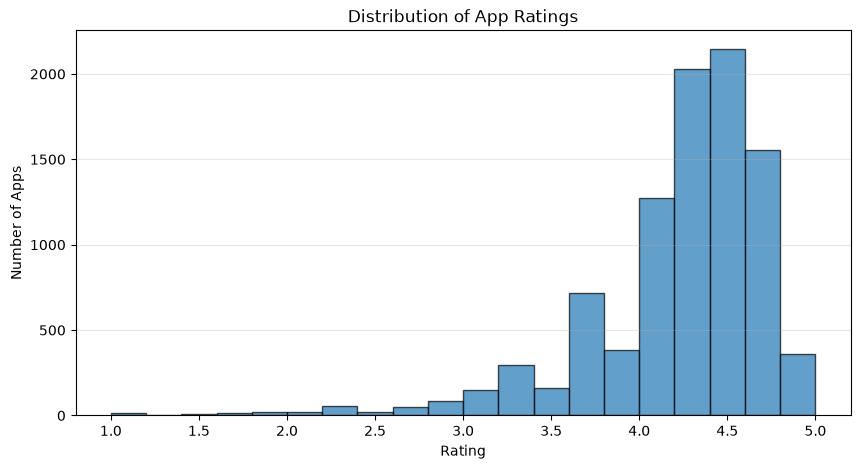

In [144]:
# Rating Distribution 
plt.figure(figsize=(10,5))
plt.hist(df_clean['Rating'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [145]:
# Top 10 categories by average rating 
category_stats = df_clean.groupby('Category').agg(
    Avg_Rating=('Rating', 'mean'),
    Count=('Rating', 'count'),
    Median_Installs=('Installs', 'median')
).reset_index()

top_categories = category_stats[category_stats['Count'] >= 10].sort_values('Avg_Rating', ascending=False).head(10)
top_categories

,Category,Avg_Rating,Count,Median_Installs
10,EVENTS,4.44,45,50000.00
8,EDUCATION,4.39,155,1000000.00
0,ART_AND_DESIGN,4.36,62,100000.00
3,BOOKS_AND_REFERENCE,4.35,178,100000.00
23,PERSONALIZATION,4.34,314,100000.00
22,PARENTING,4.30,50,100000.00
14,GAME,4.29,1097,5000000.00
2,BEAUTY,4.28,42,100000.00
15,HEALTH_AND_FITNESS,4.28,297,1000000.00
26,SHOPPING,4.26,238,1000000.00


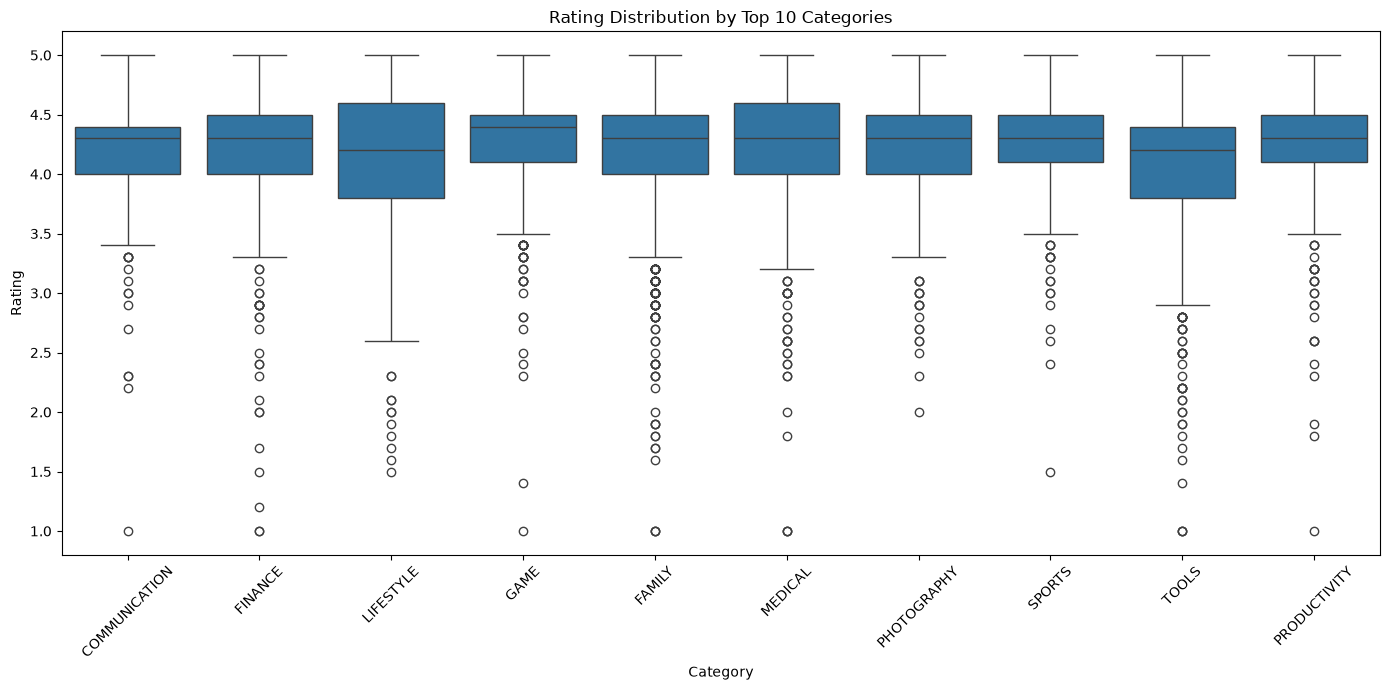

In [146]:
# Boxplot: Rating by Category (top 10 categories by count)
top_cats = df_clean['Category'].value_counts().head(10).index
df_top = df_clean[df_clean['Category'].isin(top_cats)]

plt.figure(figsize=(14,7))
sns.boxplot(data=df_top, x='Category', y='Rating')
plt.xticks(rotation=45)
plt.title('Rating Distribution by Top 10 Categories')
plt.tight_layout()
plt.show()

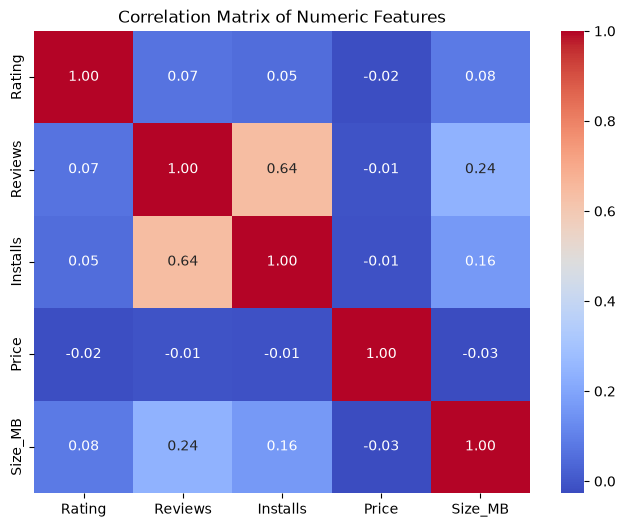

In [147]:
# Correlation heatmap (numeric columns)
numeric_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [148]:
# Free vs Paid: Average Rating & Installs
df_clean.groupby('Type').agg(
    Avg_Rating=('Rating', 'mean'),
    Median_Installs=('Installs', 'median'),
    Count=('App', 'count')
)

,Avg_Rating,Median_Installs,Count
Type,,,
Free,4.19,1000000.00,8719
Paid,4.27,5000.00,647


In [149]:
# Top 10 most installed apps
df_clean.nlargest(10, 'Installs')[['App', 'Category', 'Rating', 'Installs', 'Type', 'Price']]

,App,Category,Rating,Installs,Type,Price
152,Google Play Books,BOOKS_AND_REFERENCE,3.90,1000000000,Free,0.00
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,1000000000,Free,0.00
336,WhatsApp Messenger,COMMUNICATION,4.40,1000000000,Free,0.00
338,Google Chrome: Fast & Secure,COMMUNICATION,4.30,1000000000,Free,0.00
340,Gmail,COMMUNICATION,4.30,1000000000,Free,0.00
341,Hangouts,COMMUNICATION,4.00,1000000000,Free,0.00
381,WhatsApp Messenger,COMMUNICATION,4.40,1000000000,Free,0.00
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,1000000000,Free,0.00
386,Hangouts,COMMUNICATION,4.00,1000000000,Free,0.00
391,Skype - free IM & video calls,COMMUNICATION,4.10,1000000000,Free,0.00


### Link to Published Dashboard

## Conclusion

Markdown here

The **average rating** for apps on the Play Store is about 4.2, with most apps falling between 4.0 and 4.5. Art & Design apps have high ratings but relatively fewer installs compared to Games and Social apps. Free apps outnumber paid apps and have higher median installs, though paid apps tend to have slightly higher average ratings. There is a weak positive correlation between number of reviews and installs—more popular apps get more reviews—but rating shows virtually no correlation with app size or price.



**For developers**, free apps with in-app purchases are advisable: WHY? they drive downloads without heavily affecting the ratings. Marketers should prioritize categories with high user satisfaction like Art & Design or Education.



**For investors**, acquisition of apps with over 10 million installs and a rating above 4.5 are the strongest targets.



A few **limitations** apply to the findings: 

-Roughly 10% of ratings were missing and dropped, which may cause a slight bias in the results. 

-Some size entries were also listed as "Varies with device" and converted to missing values. 

-The dataset is from 2018, so recent trends may be different.